# AIRLINE LSTM Project
Data analysis, preprocessing, training, and model saving.

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

In [5]:
df = pd.read_csv("../data/AirPassengers.csv")

df.head()

,Month,#Passengers
0,1949-01,112
1,1949-02,118
2,1949-03,132
3,1949-04,129
4,1949-05,121


In [6]:
# Data analysis
print(df.info())
print(df.describe())
print(df.isnull().sum())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144 entries, 0 to 143
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Month        144 non-null    object
 1   #Passengers  144 non-null    int64 
dtypes: int64(1), object(1)
memory usage: 2.4+ KB
None
       #Passengers
count   144.000000
mean    280.298611
std     119.966317
min     104.000000
25%     180.000000
50%     265.500000
75%     360.500000
max     622.000000
Month          0
#Passengers    0
dtype: int64


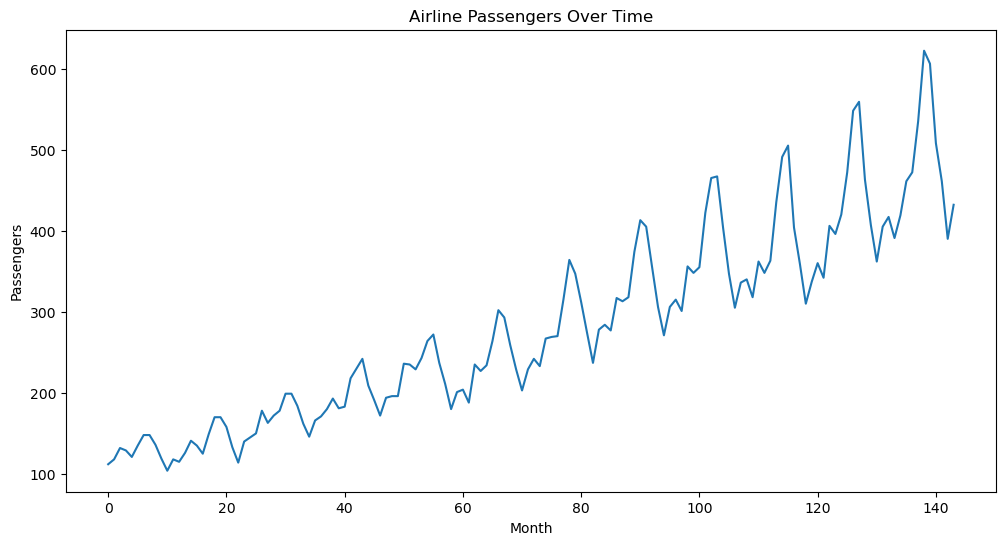

In [7]:
plt.figure(figsize=(12,6))
plt.plot(df["#Passengers"])
plt.title("Airline Passengers Over Time")
plt.xlabel("Month")
plt.ylabel("Passengers")
plt.show()

In [8]:
scaler = MinMaxScaler()

data = scaler.fit_transform(
    df[["#Passengers"]]
)

joblib.dump(
    scaler,
    "../models/scaler.pkl"
)

['../models/scaler.pkl']

In [9]:
X = []
y = []

window_size = 12

for i in range(window_size, len(data)):
    X.append(
        data[i-window_size:i, 0]
    )

    y.append(
        data[i, 0]
    )

X = np.array(X)
y = np.array(y)

X = X.reshape(
    X.shape[0],
    X.shape[1],
    1
)

print(X.shape)
print(y.shape)

(132, 12, 1)
(132,)


In [10]:
split = int(len(X)*0.8)

X_train = X[:split]
X_test = X[split:]

y_train = y[:split]
y_test = y[split:]

In [11]:
model = Sequential()

model.add(
    LSTM(
        units=64,
        return_sequences=True,
        input_shape=(12, 1)
    )
)

model.add(
    Dropout(0.2)
)

model.add(
    LSTM(
        units=32
    )
)

model.add(
    Dropout(0.2)
)

model.add(
    Dense(1)
)

model.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)

model.summary()
history = model.fit(
    X_train,
    y_train,
    epochs=100,
    batch_size=8,
    validation_data=(X_test, y_test),
    verbose=1
)

c:\Users\harsh\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 12, 64)         │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 12, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,345 (114.63 KB)

 Trainable params: 29,345 (114.63 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 3s 40ms/step - loss: 0.0544 - mae: 0.1722 - val_loss: 0.0220 - val_mae: 0.1278
Epoch 2/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0159 - mae: 0.1040 - val_loss: 0.0582 - val_mae: 0.1919
Epoch 3/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0121 - mae: 0.0772 - val_loss: 0.0218 - val_mae: 0.1232
Epoch 4/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0096 - mae: 0.0811 - val_loss: 0.0309 - val_mae: 0.1262
Epoch 5/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0096 - mae: 0.0706 - val_loss: 0.0217 - val_mae: 0.1220
Epoch 6/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0102 - mae: 0.0732 - val_loss: 0.0214 - val_mae: 0.1171
Epoch 7/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0104 - mae: 0.0751 - val_loss: 0.0247 - val_mae: 0.1161
Epoch 8/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0092 - mae: 0.0676 - val_loss: 0.0226 - val_mae: 0.1308
Epoch 9/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - los

In [12]:
predictions = model.predict(X_test)

predictions = scaler.inverse_transform(predictions)

actual = scaler.inverse_transform(
    y_test.reshape(-1,1)
)

from sklearn.metrics import mean_squared_error
import numpy as np

rmse = np.sqrt(
    mean_squared_error(
        actual,
        predictions
    )
)

print("RMSE:", rmse)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 256ms/step
RMSE: 77.3184297363522


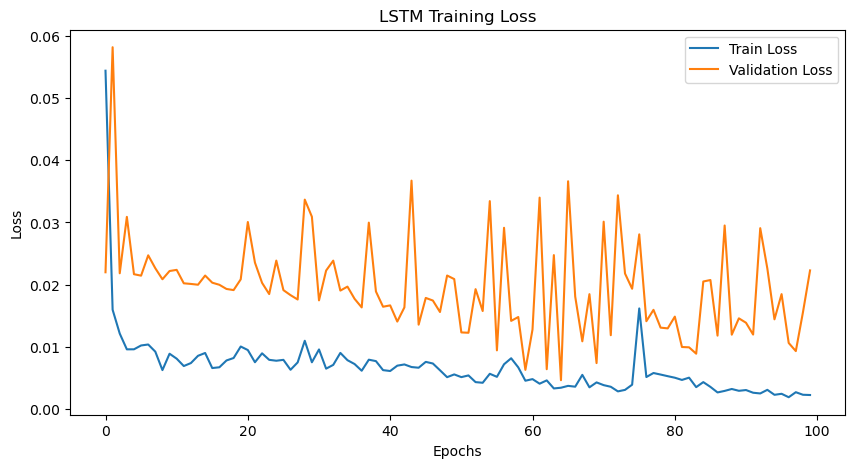

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("LSTM Training Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [15]:
model.save(
    "../models/airline_lstm.keras"
)
print("Model Saved")

Model Saved
